---
title: Non-stationary GEV — a parametric trend
subtitle: A time-varying location for a warming climate, at one long station
short_title: Non-stationary (parametric)
authors:
  - name: Juan Emmanuel Johnson
date: 2026-06-09
keywords:
  - non-stationary extremes
  - GEV
  - climate trend
  - return levels
  - NUTS
abstract: |
  Every model so far has assumed the GEV parameters are fixed in time. Over a
  century of records that assumption is wrong: the climate warms, and the
  distribution of annual maxima drifts with it. This notebook makes the GEV
  *non-stationary* in the simplest, most interpretable way — a linear trend in
  the location, $\mu(t)=\mu_0+\mu_1 z(t)$ — fit by NUTS to the longest single
  station in the record (Albacete, 1901–2025). We test whether the trend is
  real (WAIC against the stationary model), read it off in °C per decade, and
  see the headline consequence: **return levels are now a function of time**.
---

# Non-stationary extremes: a parametric trend

The pooling and spatial notebooks ([](../02_pooling/05_hierarchical_pooling.ipynb),
[](../03_spatial_gev/07_spatial_gp_mu.ipynb)) borrowed strength across *space* to
sharpen a GEV fit, but every one of them held the parameters **fixed in time** —
the 1901 annual maximum and the 2025 one were treated as draws from the same
distribution. For temperature over a warming century that is exactly the
assumption we should distrust.

This is the first of three notebooks that let the GEV drift in time at a **single
long station**, escalating in flexibility:

1. **parametric** (this notebook) — a rigid linear trend, the textbook model;
2. **ODE** ([](11_nonstationary_ode.ipynb)) — a mechanistic, forced-relaxation trajectory;
3. **GP** ([](12_nonstationary_gp.ipynb)) — a nonparametric smooth curve.

Same station, same GEV likelihood, same NUTS sampler throughout — only the model
of *how the parameters move* changes.

## Background

### A time-varying GEV

We keep the GEV of [](../01_evt_foundations/02_gev_one_station.ipynb) but let the
**location** depend on a covariate. With $z(t)$ a standardized index of the year,

```{math}
:label: eq:ns-gev
Y_t \sim \mathrm{GEV}\!\bigl(\mu(t),\,\sigma,\,\xi\bigr),
\qquad
\mu(t) = \mu_0 + \mu_1\, z(t),
```

so $\mu_1$ is the shift in the centre of the annual-maximum distribution per unit
of $z$. We hold the **scale** $\sigma$ and **shape** $\xi$ constant: with ~115
maxima there is signal for a trend in the *centre*, but pinning a trend in the
*spread* or the *tail type* is much harder (we add a scale trend as an extension
at the end, and devote the GP notebook to flexible shapes).

This is Coles' non-stationary GEV (Coles 2001, ch. 6). The log-likelihood is the
stationary one {eq}`eq:gev-loglik` with $\mu$ replaced block-by-block by
$\mu(t)$; xtremax assembles those per-block fields with
`assemble_nonstationary_gev_fields`.

### Return levels become time-dependent

The crucial consequence: the **$T$-year return level is no longer a single
number**. Reading {eq}`eq:gev-rl` at the parameters of a given year gives an
*instantaneous* return level $z_T(t)$ — "the 1-in-100-year heat *for the climate
of year $t$*". A fixed physical threshold that was a 1-in-100-year event in 1901
is, under a warmed $\mu(2025)$, a far more frequent event. We make both views
concrete below.

## Setup

In [1]:
import sys
import pathlib

try:
    import spatial_extremes  # noqa: F401  installed editable in the project venv
except ModuleNotFoundError:
    _here = pathlib.Path.cwd().resolve()
    _roots = (_here, *_here.parents)
    _cands = [r / "src" for r in _roots]
    _cands += [r / "projects" / "spatial_extremes" / "src" for r in _roots]
    _src = next((c for c in _cands if (c / "spatial_extremes").exists()), None)
    if _src is None:
        raise RuntimeError("cannot locate spatial_extremes/src") from None
    sys.path.insert(0, str(_src))

In [2]:
from __future__ import annotations

import warnings
warnings.filterwarnings("ignore", message=r".*IProgress.*")

import jax
jax.config.update("jax_enable_x64", True)        # GEV likelihood is boundary-sensitive

import numpy as np
import pandas as pd
import jax.numpy as jnp
import jax.random as jr
from jax.scipy.special import logsumexp
import matplotlib.pyplot as plt
import seaborn as sns

import numpyro
import numpyro.distributions as ndist
from numpyro.infer import MCMC, NUTS
from numpyro.infer.initialization import init_to_median

from xtremax import GeneralizedExtremeValueDistribution as GEV
from xtremax import gev_log_prob, gev_survival, assemble_nonstationary_gev_fields

from spatial_extremes import data, viz

sns.set_theme(style="whitegrid", context="notebook", palette="deep")

In [3]:
# Longest continuous single-station record in the cache: Albacete, 1901-2025.
years, maxima, meta = data.load_single_station()
place = meta["name"]
y_np = np.asarray(maxima, float)
yr = np.asarray(years, int)
m = y_np.size

# Standardized year covariate z(t) — the trend predictor. Centring makes mu0 the
# location at the middle of the record and decorrelates it from the slope mu1.
yr_mean, yr_std = float(yr.mean()), float(yr.std())
z_np = (yr - yr_mean) / yr_std

y = jnp.asarray(y_np)
z = jnp.asarray(z_np)
y_mean, y_std = float(y.mean()), float(y.std())
per_decade = 10.0 / yr_std          # convert a per-unit-z slope to degC/decade

print("source:", "REAL CDS" if meta["is_real"] else "synthetic")
print(f"{place} ({meta['lon']:.2f} degE, {meta['lat']:.2f} degN) — id {meta['station_id']}")
print(f"{m} annual maxima, {yr.min()}-{yr.max()}, {y_np.min():.1f}-{y_np.max():.1f} degC")

source: REAL CDS
Albacete (-1.86 degE, 38.95 degN) — id SP000008280
115 annual maxima, 1901-2025, 35.0-45.0 degC


The record is long enough to *see* a drift by eye. Here are the annual maxima
through time, with a least-squares line for orientation, and a locator map:

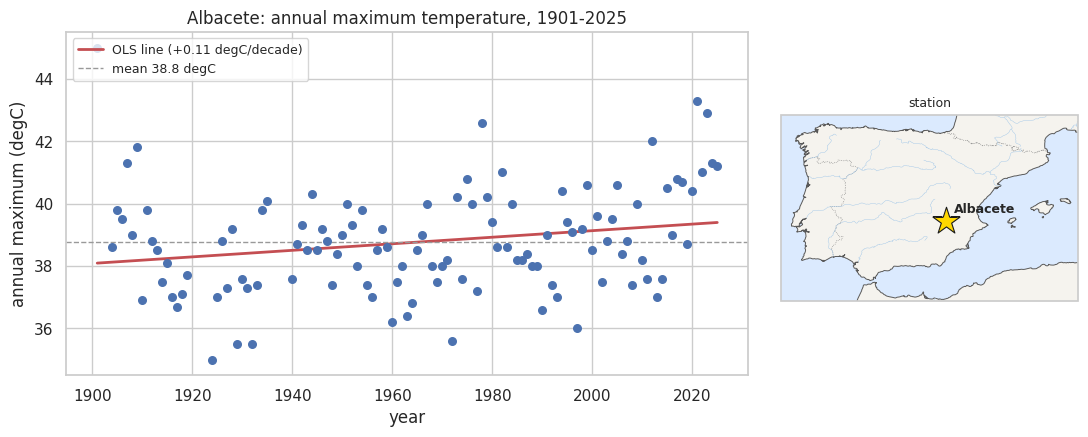

In [4]:
ols = np.polyfit(yr, y_np, 1)        # crude visual slope (degC/yr)
fig = plt.figure(figsize=(11, 4.4))
ax = fig.add_axes([0.07, 0.12, 0.62, 0.78])
ax.scatter(yr, y_np, color="#4C72B0", s=30, zorder=3)
ax.plot(yr, np.polyval(ols, yr), color="#C44E52", lw=2,
        label=f"OLS line ({ols[0]*10:+.2f} degC/decade)")
ax.axhline(y_np.mean(), color="0.6", ls="--", lw=1, label=f"mean {y_np.mean():.1f} degC")
ax.set(xlabel="year", ylabel="annual maximum (degC)",
       title=f"{place}: annual maximum temperature, {yr.min()}-{yr.max()}")
ax.legend(loc="upper left", fontsize=9)

# locator map: reuse the project's Iberia helper on a small inset axis
import cartopy.crs as ccrs
gax = fig.add_axes([0.72, 0.08, 0.27, 0.84], projection=ccrs.PlateCarree())
viz.iberia_axes(gax, gridlines=False)
viz.mark_star(gax, meta["lon"], meta["lat"], label=place)
gax.set_title("station", fontsize=9)
plt.show()

## A stationary fit, and why it is not enough

First the honest baseline: fit the **stationary** GEV (constant $\mu,\sigma,\xi$)
exactly as in [](../01_evt_foundations/02_gev_one_station.ipynb). It will fit the
*marginal* histogram perfectly well — the tell-tale of misspecification is in the
**residuals against time**.

In [5]:
def gev_stationary(obs):
    mu = numpyro.sample("mu", ndist.Normal(y_mean, 5.0))
    sigma = numpyro.sample("sigma", ndist.HalfNormal(y_std))
    xi = numpyro.sample("xi", ndist.Normal(0.0, 0.25))
    numpyro.sample("obs", GEV(loc=mu, scale=sigma, concentration=xi), obs=obs)

mcmc0 = MCMC(NUTS(gev_stationary, target_accept_prob=0.99, init_strategy=init_to_median),
             num_warmup=1500, num_samples=1500, num_chains=2,
             chain_method="vectorized", progress_bar=False)
mcmc0.run(jr.PRNGKey(0), y)
post0 = mcmc0.get_samples()
mu0_m, sig0_m, xi0_m = (float(np.median(post0[k])) for k in ("mu", "sigma", "xi"))
print(f"stationary fit:  mu={mu0_m:.2f}  sigma={sig0_m:.2f}  xi={xi0_m:+.3f}")
print(f"divergences: {int(mcmc0.get_extra_fields()['diverging'].sum())}")

stationary fit:  mu=38.07  sigma=1.54  xi=-0.115
divergences: 6


The diagnostic: transform each maximum to its fitted GEV probability
$\hat G(z_i)$ (a *PIT* value, uniform on $[0,1]$ if the model is right) and plot
it against the year. Under a stationary model these should show **no trend** — a
flat cloud. A drift means early years sit low (their maxima are small for the
fitted distribution) and late years sit high.

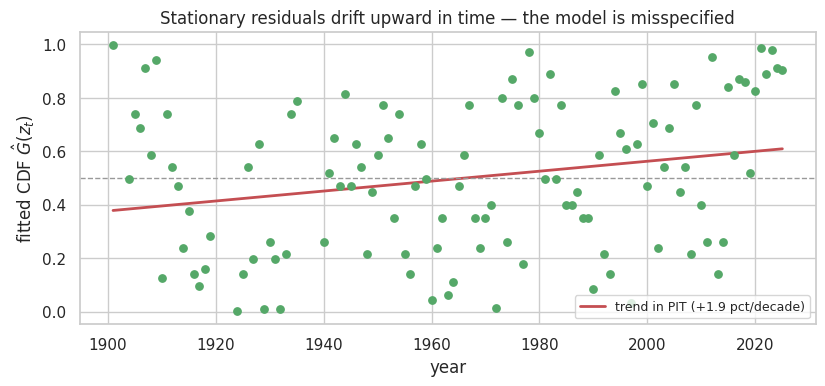

In [6]:
pit = np.asarray(GEV(loc=mu0_m, scale=sig0_m, concentration=xi0_m).cdf(y))
slope_pit = np.polyfit(yr, pit, 1)[0]
fig, ax = plt.subplots(figsize=(9.5, 3.8))
ax.scatter(yr, pit, color="#55A868", s=28, zorder=3)
ax.plot(yr, np.polyval(np.polyfit(yr, pit, 1), yr), color="#C44E52", lw=2,
        label=f"trend in PIT ({slope_pit*100*10:+.1f} pct/decade)")
ax.axhline(0.5, color="0.6", ls="--", lw=1)
ax.set(xlabel="year", ylabel=r"fitted CDF $\hat G(z_t)$",
       title="Stationary residuals drift upward in time — the model is misspecified")
ax.legend(fontsize=9)
plt.show()

## Letting the location drift: $\mu(t)=\mu_0+\mu_1 z(t)$

Now the non-stationary model {eq}`eq:ns-gev`. The only change from the baseline is
a second location parameter $\mu_1$ multiplying the standardized year $z(t)$; we
build the per-block location field with xtremax's
`assemble_nonstationary_gev_fields` (`n_sites=1` here — the same primitive the
spatial notebooks use across many sites).

In [7]:
def gev_trend(obs, zcov):
    mu0 = numpyro.sample("mu0", ndist.Normal(y_mean, 5.0))   # location at mid-record
    mu1 = numpyro.sample("mu1", ndist.Normal(0.0, 2.0))      # trend per unit z
    log_sigma = numpyro.sample("log_sigma", ndist.Normal(np.log(y_std), 0.5))
    xi = numpyro.sample("xi", ndist.Normal(0.0, 0.25))
    # (n_blocks, n_sites=1) fields -> squeeze the singleton site axis
    loc, scale, shape = assemble_nonstationary_gev_fields(
        mu0[None], mu1[None], log_sigma[None], xi, zcov)
    numpyro.sample("obs", GEV(loc=loc[:, 0], scale=scale[:, 0],
                              concentration=shape[:, 0]), obs=obs)

mcmc1 = MCMC(NUTS(gev_trend, target_accept_prob=0.99, init_strategy=init_to_median),
             num_warmup=1500, num_samples=1500, num_chains=2,
             chain_method="vectorized", progress_bar=False)
mcmc1.run(jr.PRNGKey(1), y, z)
mcmc1.print_summary()
post1 = mcmc1.get_samples()
print(f"divergences: {int(mcmc1.get_extra_fields()['diverging'].sum())}")


                 mean       std    median      5.0%     95.0%     n_eff     r_hat
  log_sigma      0.40      0.07      0.40      0.28      0.51   2049.64      1.00
        mu0     38.07      0.15     38.07     37.82     38.31   2056.60      1.00
        mu1      0.41      0.16      0.41      0.14      0.66   2525.02      1.00
         xi     -0.09      0.05     -0.09     -0.16     -0.01   1883.60      1.00

Number of divergences: 2
divergences: 2


### Reading the trend

The slope $\mu_1$ is in °C per unit of $z$; multiplying by $10/\mathrm{sd}(\text{year})$
puts it in the units a climatologist wants — **°C per decade** — and integrating
across the record gives the total warming of the distribution's centre.

In [8]:
mu1 = np.asarray(post1["mu1"])
slope_dec = mu1 * per_decade                       # degC/decade
total = mu1 * (z_np.max() - z_np.min())            # degC over the whole record
def ci(a): return np.quantile(a, [0.025, 0.5, 0.975])
lo, md_, hi = ci(slope_dec)
tlo, tmd, thi = ci(total)
p_pos = float((mu1 > 0).mean())
print(f"warming of the location:")
print(f"  slope   {md_:+.3f} degC/decade   (95% CI {lo:+.3f}, {hi:+.3f})")
print(f"  total   {tmd:+.2f} degC over {yr.min()}-{yr.max()}  (95% CI {tlo:+.2f}, {thi:+.2f})")
print(f"  P(mu1 > 0 | data) = {p_pos:.3f}")

warming of the location:
  slope   +0.115 degC/decade   (95% CI +0.026, +0.202)
  total   +1.43 degC over 1901-2025  (95% CI +0.32, +2.50)
  P(mu1 > 0 | data) = 0.994


## Is the trend real? Model comparison with WAIC

A non-zero slope in a richer model is not by itself evidence — the extra
parameter can fit noise. The **Watanabe–Akaike Information Criterion (WAIC)**
weighs fit against effective complexity using the full posterior, with no extra
dependencies: from the pointwise log-likelihoods $\ell_{s,i}=\log p(y_i\mid
\theta_s)$ over draws $s$,

$$\mathrm{lppd}=\sum_i \log\tfrac1S\sum_s e^{\ell_{s,i}},\quad
p_{\mathrm{WAIC}}=\sum_i \mathrm{Var}_s\,\ell_{s,i},\quad
\mathrm{WAIC}=-2(\mathrm{lppd}-p_{\mathrm{WAIC}}).$$

Lower is better; a drop of more than a few points is meaningful.

In [9]:
def pointwise_ll_stationary(post, y):
    mu = post["mu"][:, None]; sig = post["sigma"][:, None]; xi = post["xi"][:, None]
    return gev_log_prob(y[None, :], mu, sig, xi)              # (S, T)

def pointwise_ll_trend(post, y, z):
    loc = post["mu0"][:, None] + post["mu1"][:, None] * z[None, :]
    sig = jnp.exp(post["log_sigma"])[:, None]; xi = post["xi"][:, None]
    return gev_log_prob(y[None, :], loc, sig, xi)             # (S, T)

def waic(ll):
    S = ll.shape[0]
    lppd = logsumexp(ll, axis=0) - jnp.log(S)
    p_w = ll.var(axis=0)
    w = -2.0 * (lppd.sum() - p_w.sum())
    return float(w), float(p_w.sum())

w0, p0 = waic(pointwise_ll_stationary(post0, y))
w1, p1 = waic(pointwise_ll_trend(post1, y, z))
tab = pd.DataFrame({"WAIC": [w0, w1], "p_eff": [p0, p1]},
                   index=["stationary", "linear trend mu(t)"])
tab["dWAIC"] = tab["WAIC"] - tab["WAIC"].min()
print(tab.round(2).to_string())
print(f"\nWAIC improves by {w0 - w1:.1f} when the location is allowed to drift.")

                      WAIC  p_eff  dWAIC
stationary          447.85   3.02   4.67
linear trend mu(t)  443.18   4.21   0.00

WAIC improves by 4.7 when the location is allowed to drift.


## Time-varying return levels

The payoff. Evaluating the return-level formula {eq}`eq:gev-rl` at each year's
parameters turns the single return-level curve of the stationary model into a
**family of curves indexed by year**. We contrast the start and the end of the
record, propagating posterior uncertainty. The observed maxima are plotted **at
their own year's climate** — each point sits at the return period $T_t = 1/(1 -
\hat G(y_t;\,\theta_t))$ implied by the fitted GEV for *that* year, and is
coloured by year. Because every point lies on its own-year curve, and those
curves lie between the two we draw, the cloud drifts from the early (blue)
envelope up to the recent (red) one — the data live *between* the climates, not
on either single one.

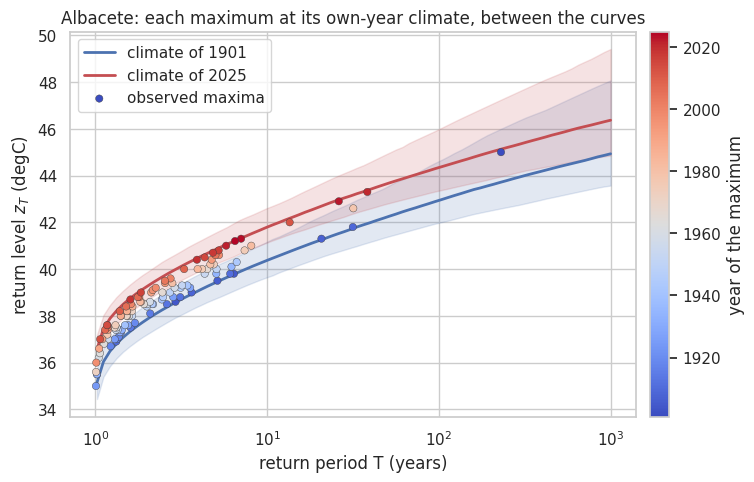

In [10]:
# Place each observed maximum at ITS OWN year's climate: compute the return
# period of y(t) under the fitted GEV for year t, T_t = 1 / (1 - G(y_t; theta_t)).
# By construction the point (T_t, y_t) lies on the year-t return curve, which sits
# *between* the two reference curves — so the cloud migrates from the early to the
# recent envelope as the years warm. (Median posterior parameters.)
mu0_m = float(np.median(post1["mu0"]))
mu1_m = float(np.median(post1["mu1"]))
sig_m = float(np.exp(np.median(post1["log_sigma"])))
xi_m = float(np.median(post1["xi"]))
loc_t = mu0_m + mu1_m * z_np
p_t = np.asarray(GEV(loc=jnp.asarray(loc_t), scale=sig_m, concentration=xi_m).cdf(y))
p_t = np.clip(p_t, None, 1.0 - 0.5 / m)        # cap the record max so T_t is finite
T_own = 1.0 / (1.0 - p_t)

# Start the curves at the smallest observed return period (a hair above 1) so the
# bands reach down to the leftmost points, rather than the conventional T=2 anchor.
t_lo = max(1.02, float(T_own.min()))
periods = jnp.logspace(np.log10(t_lo), 3, 80)
sub = jr.choice(jr.PRNGKey(3), post1["mu0"].size, (800,), replace=False)

def rl_curves_at(zt):
    loc = post1["mu0"][sub] + post1["mu1"][sub] * zt
    sig = jnp.exp(post1["log_sigma"])[sub]; xi = post1["xi"][sub]
    rl = jax.vmap(lambda i: GEV(loc=loc[i], scale=sig[i], concentration=xi[i])
                  .return_level(periods))(jnp.arange(loc.size))
    return np.asarray(rl)

z_first, z_last = float(z_np[0]), float(z_np[-1])
rl_first = rl_curves_at(z_first)
rl_last = rl_curves_at(z_last)

fig, ax = plt.subplots(figsize=(8.8, 5))
for rl, c, lab in [(rl_first, "#4C72B0", f"climate of {yr.min()}"),
                   (rl_last, "#C44E52", f"climate of {yr.max()}")]:
    med, loq, hiq = (np.quantile(rl, q, 0) for q in (0.5, 0.025, 0.975))
    ax.fill_between(np.asarray(periods), loq, hiq, color=c, alpha=0.16)
    ax.plot(np.asarray(periods), med, color=c, lw=2, label=lab)
sc = ax.scatter(T_own, y_np, c=yr, cmap="coolwarm", s=28, zorder=6,
                edgecolor="0.25", linewidth=0.3, label="observed maxima")
cb = fig.colorbar(sc, ax=ax, pad=0.02)
cb.set_label("year of the maximum")
ax.set_xscale("log")
ax.set(xlabel="return period T (years)", ylabel=r"return level $z_T$ (degC)",
       title=f"{place}: each maximum at its own-year climate, between the curves")
ax.legend(loc="upper left")
plt.show()

And the table that an engineer would read — the same design return periods,
for the climate of the first year versus the last:

In [11]:
rows = []
for T in (10, 25, 50, 100, 200):
    iT = int(np.argmin(np.abs(np.asarray(periods) - T)))
    a, b = rl_first[:, iT], rl_last[:, iT]
    rows.append((T, np.median(a), np.median(b), np.median(b) - np.median(a)))
rl_tab = pd.DataFrame(rows, columns=["T (yr)", f"{yr.min()} degC",
                                     f"{yr.max()} degC", "shift degC"]).set_index("T (yr)")
print(rl_tab.round(2).to_string())

        1901 degC  2025 degC  shift degC
T (yr)                                  
10          40.35      41.77        1.42
25          41.50      42.94        1.44
50          42.26      43.69        1.42
100         42.97      44.38        1.40
200         43.63      45.04        1.41


### The same threshold, a shorter wait

Flip it around. Take the level that was a **1-in-100-year** maximum in the climate
of the first year, then ask how often that same temperature is exceeded under the
final-year distribution. A century of warming turns a 1-in-100 event into a
far more frequent one — the single most intuitive statement of non-stationary
risk.

In [12]:
# z100 for the first-year climate (posterior median params)
p0m = {k: np.median(post1[k]) for k in ("mu0", "mu1", "log_sigma", "xi")}
loc_first = p0m["mu0"] + p0m["mu1"] * z_first
loc_last = p0m["mu0"] + p0m["mu1"] * z_last
sig_m, xi_m = np.exp(p0m["log_sigma"]), p0m["xi"]
z100_first = float(GEV(loc=loc_first, scale=sig_m, concentration=xi_m)
                   .return_level(jnp.array(100.0)))
# return period of that threshold under the final-year climate: T = 1 / P(Y>z)
surv = float(gev_survival(jnp.array(z100_first), loc_last, sig_m, xi_m))
T_now = 1.0 / surv
print(f"The {yr.min()} 1-in-100-year maximum is {z100_first:.1f} degC.")
print(f"Under the {yr.max()} climate, that level is exceeded about 1-in-{T_now:.0f} years.")

The 1901 1-in-100-year maximum is 42.9 degC.
Under the 2025 climate, that level is exceeded about 1-in-26 years.


## Extension: a trend in the scale, too

Warming can change not just the centre but the *spread* of summer maxima. We let
$\log\sigma$ drift as well, $\log\sigma(t)=s_0+s_1 z(t)$, and check whether the
data ask for it (does $s_1$'s credible interval exclude zero, and does WAIC
improve further?).

In [13]:
def gev_trend_sigma(obs, zcov):
    mu0 = numpyro.sample("mu0", ndist.Normal(y_mean, 5.0))
    mu1 = numpyro.sample("mu1", ndist.Normal(0.0, 2.0))
    s0 = numpyro.sample("s0", ndist.Normal(np.log(y_std), 0.5))
    s1 = numpyro.sample("s1", ndist.Normal(0.0, 0.5))
    xi = numpyro.sample("xi", ndist.Normal(0.0, 0.25))
    loc = mu0 + mu1 * zcov
    scale = jnp.exp(s0 + s1 * zcov)
    numpyro.sample("obs", GEV(loc=loc, scale=scale, concentration=xi), obs=obs)

mcmc2 = MCMC(NUTS(gev_trend_sigma, target_accept_prob=0.99, init_strategy=init_to_median),
             num_warmup=1500, num_samples=1500, num_chains=2,
             chain_method="vectorized", progress_bar=False)
mcmc2.run(jr.PRNGKey(2), y, z)
post2 = mcmc2.get_samples()
s1 = np.asarray(post2["s1"]); s1lo, s1md, s1hi = ci(s1)

def ll_trend_sigma(post, y, z):
    loc = post["mu0"][:, None] + post["mu1"][:, None] * z[None, :]
    scale = jnp.exp(post["s0"][:, None] + post["s1"][:, None] * z[None, :])
    return gev_log_prob(y[None, :], loc, scale, post["xi"][:, None])
w2, p2 = waic(ll_trend_sigma(post2, y, z))
print(f"scale trend s1 = {s1md:+.3f}  (95% CI {s1lo:+.3f}, {s1hi:+.3f})")
print(f"WAIC: stationary {w0:.1f} | mu-trend {w1:.1f} | mu+sigma-trend {w2:.1f}")
verdict = "excludes 0 — the spread is changing too" if (s1lo > 0 or s1hi < 0) \
    else "straddles 0 — no clear evidence the spread changes"
print(f"s1 {verdict}.")

scale trend s1 = -0.052  (95% CI -0.171, +0.071)
WAIC: stationary 447.8 | mu-trend 443.2 | mu+sigma-trend 444.7
s1 straddles 0 — no clear evidence the spread changes.


## Recap & where next

We made the GEV non-stationary the textbook way — a **linear trend in the
location**, $\mu(t)=\mu_0+\mu_1 z(t)$ — fit it by NUTS to Albacete's 1901–2025
record, and confirmed with WAIC that the drift is real and not over-fitting. The
trend reads as a warming of the annual-maximum *centre* of a few tenths of a
degree per decade, and it rewrites the engineering numbers: **return levels are
now functions of time**, and a fixed threshold that was rare a century ago
recurs far more often today.

A straight line is the strongest possible assumption about the *shape* of the
trend — it cannot bend, plateau, or accelerate, and it extrapolates without
limit. The next notebook, [](11_nonstationary_ode.ipynb), replaces the line with a
**mechanistic ODE**: the location follows a forced-relaxation trajectory with a
physical timescale, a grey-box midpoint between this rigid parametric form and
the fully nonparametric Gaussian process of [](12_nonstationary_gp.ipynb).